# Medical Diagnosis Exercise

This notebook studies an imbalanced breast cancer screening problem. The main priority is high recall on the cancer class.

## Dependency note

This notebook relies on the imbalanced-learn package for SMOTE, Borderline-SMOTE, and ADASYN. In the repository version, dependencies should be installed in the project environment before the notebook is executed.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import PrecisionRecallDisplay, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# Build an imbalanced screening dataset to mimic a difficult medical detection task.
data = load_breast_cancer()
X_raw = data.data
y_raw = (data.target == 0).astype(int)  # 1 = cancer, 0 = healthy

rng = np.random.RandomState(42)
idx_healthy = np.where(y_raw == 0)[0]
idx_cancer = np.where(y_raw == 1)[0]
idx_cancer_sub = rng.choice(idx_cancer, size=30, replace=False)
idx_final = np.concatenate([idx_healthy, idx_cancer_sub])

X = X_raw[idx_final]
y = y_raw[idx_final]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Class distribution in the training set:")
print(pd.Series(y_train).value_counts().rename(index={0: "Healthy", 1: "Cancer"}))

Class distribution in the training set:
Healthy    249
Cancer      21
Name: count, dtype: int64


In [3]:
# Compare a plain logistic model with cost-sensitive and oversampling variants.
base_clf = LogisticRegression(solver="saga", max_iter=5000, random_state=42)

models = {
    "Baseline": base_clf,
    "Cost-Sensitive": LogisticRegression(
        solver="saga", max_iter=5000, random_state=42, class_weight="balanced"
    ),
    "SMOTE": ImbPipeline([("smote", SMOTE(random_state=42)), ("clf", base_clf)]),
    "Borderline-SMOTE": ImbPipeline([("bsmote", BorderlineSMOTE(random_state=42)), ("clf", base_clf)]),
    "ADASYN": ImbPipeline([("adasyn", ADASYN(random_state=42)), ("clf", base_clf)]),
}

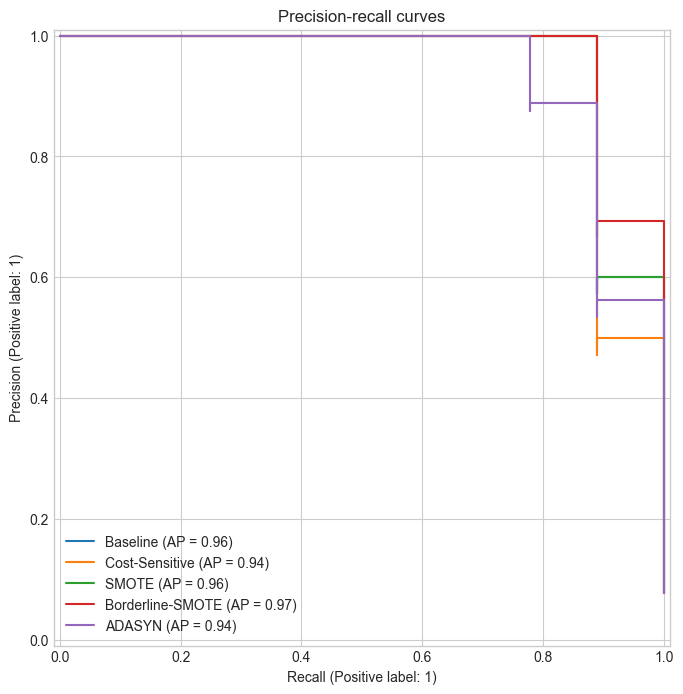

,Model,Recall,F1-score
1,Cost-Sensitive,0.888889,0.888889
3,Borderline-SMOTE,0.888889,0.941176
2,SMOTE,0.888889,0.941176
4,ADASYN,0.888889,0.888889
0,Baseline,0.777778,0.875000


In [4]:
# Evaluate each strategy with recall, F1-score, and the precision-recall curve.
results = []
predictions = {}

fig, ax = plt.subplots(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    results.append({
        "Model": name,
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
    })

    if hasattr(model, "predict_proba"):
        PrecisionRecallDisplay.from_estimator(model, X_test_scaled, y_test, name=name, ax=ax)

plt.title("Precision-recall curves")
plt.show()

results_df = pd.DataFrame(results).sort_values("Recall", ascending=False)
display(results_df)

Best model: Cost-Sensitive
              precision    recall  f1-score   support

     Healthy       0.99      0.99      0.99       108
      Cancer       0.89      0.89      0.89         9

    accuracy                           0.98       117
   macro avg       0.94      0.94      0.94       117
weighted avg       0.98      0.98      0.98       117



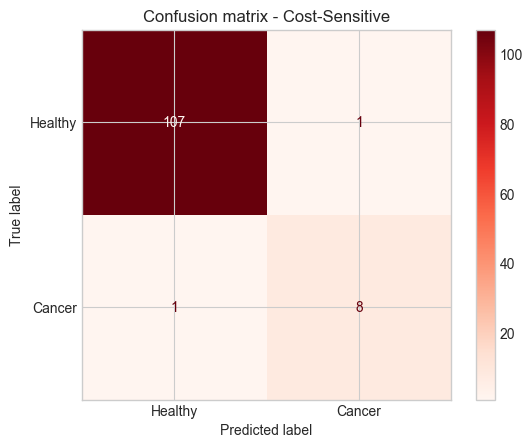

In [5]:
# Report the best-performing model in more detail.
best_model_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_model_name]

print("Best model:", best_model_name)
print(classification_report(y_test, best_pred, target_names=["Healthy", "Cancer"]))

ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred, display_labels=["Healthy", "Cancer"], cmap="Reds"
)
plt.title(f"Confusion matrix - {best_model_name}")
plt.show()

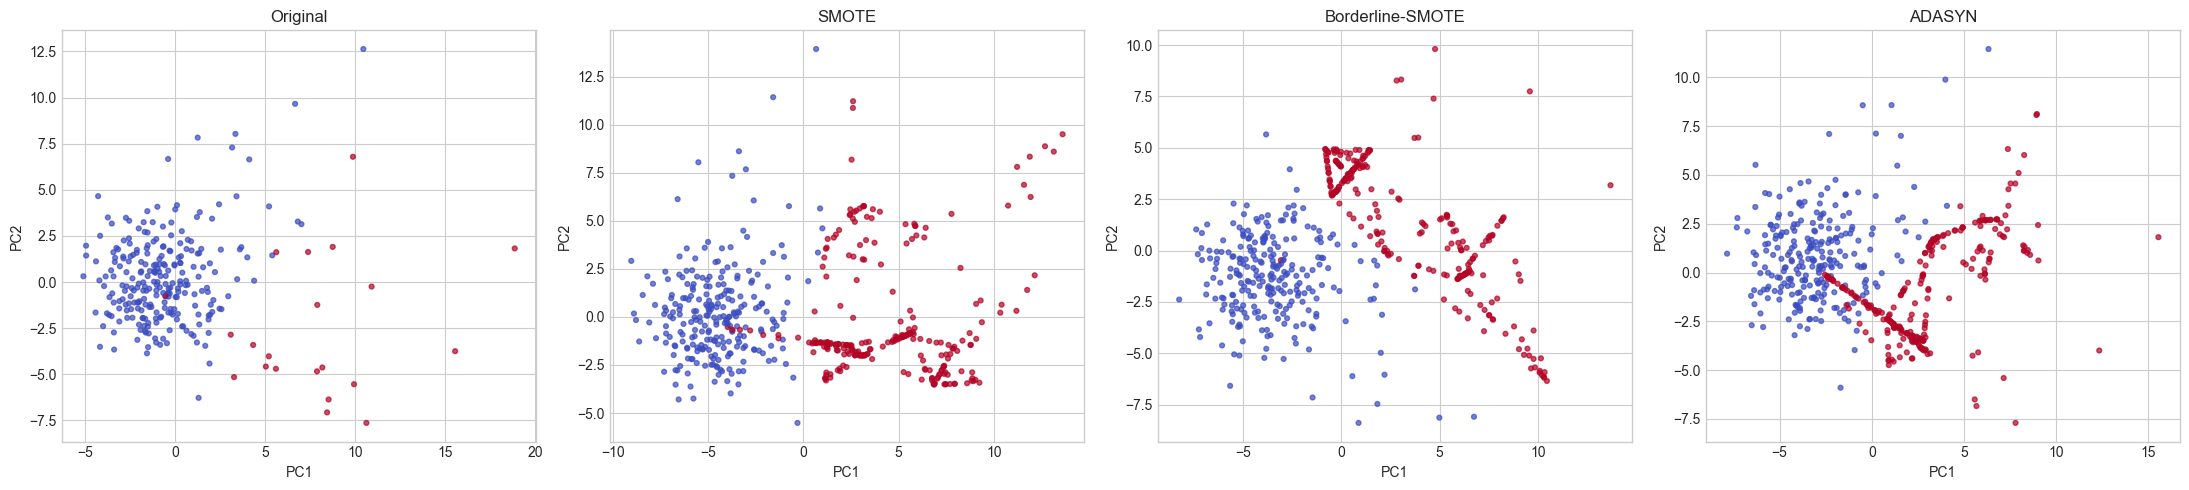

In [6]:
# Visualize how oversampling changes the minority class in a 2D PCA projection.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

samplers = [
    (None, "Original"),
    (SMOTE(random_state=42), "SMOTE"),
    (BorderlineSMOTE(random_state=42), "Borderline-SMOTE"),
    (ADASYN(random_state=42), "ADASYN"),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (sampler, title) in zip(axes, samplers):
    if sampler is None:
        X_vis, y_vis = X_train_scaled, y_train
    else:
        X_vis, y_vis = sampler.fit_resample(X_train_scaled, y_train)

    X_vis_pca = pca.fit_transform(X_vis)
    ax.scatter(X_vis_pca[:, 0], X_vis_pca[:, 1], c=y_vis, cmap="coolwarm", s=12, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

## Interpretation

The oversampling methods increase the presence of the minority class in the training space. This helps logistic regression learn a less biased decision boundary.

In a medical screening context, a model with stronger recall is generally preferred, even if precision decreases somewhat.

## Explicit Answer to the Sampling Question

The PCA projections show that the original dataset contains very few cancer observations, concentrated in a small region of the feature space. After oversampling, the minority class occupies a broader area and the red points are no longer isolated.

SMOTE generally creates a smoother and more continuous minority cloud. Borderline-SMOTE concentrates synthetic examples near the overlap between healthy and cancer cases, which is useful when the objective is to improve the decision boundary. ADASYN tends to generate more synthetic points around difficult minority observations, which can make the minority region look more irregular.

These synthetic samples help logistic regression because the model sees more representative cancer patterns during training instead of a tiny and underrepresented class. In a screening context, this is especially useful when the priority is high recall: enlarging the minority class reduces the tendency to classify borderline cancer cases as healthy.
